## AAI6640 2026 Spring Assignment 2

# Section One: Initialization 

In [49]:
# Verify libary versions for reproducibility
import torch
import torchvision
import numpy as np

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('numpy:', np.__version__)

torch: 2.10.0
torchvision: 0.25.0
numpy: 2.4.2


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
datasets.MNIST.mirrors = ['https://ossci-datasets.s3.amazonaws.com/mnist/']

# 1. Load MNIST Dataset
# implementing normalization: 0.1307 represents the mean and 0.3081 represents std, these are used for consistent input scaling across the dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)

## <div class="alert alert-info">[GRADED  TASK 1.1]</div>
Please use the given MNIST data to compare three different initialization methods - xaiver normal, kaiming normal, zero.

The model is a MLP with two hidden layers - 256 & 128 neuros each.

In [ ]:
# Your answer here


'''
MLP architecture:
- Input layer: 784 neurons (28x28 pixels flattened)
- Hidden layer 1: 256 neurons + ReLU activation
- Hidden layer 2: 128 neurons + ReLU activation
- Output layer: 10 neurons (for 10 classes) + no activation (logits)

Implemented a class SimpleNN that inherits from nn.Module. I chose this architecture because its common for image classification tasks like MINST.
- super is used to call the __init__ method of the parent class nn.Module to ensure proper initialization of the model
- the forward method helps with the foward pass of the model, helps with he input flow through the layers and activations, returns the output logits for classification




'''

class SimpleNN(nn.Module):
    def __init__(self):
        # super is used to call the __init__ method of the parent class (nn.Module) to ensure proper initialization of the model
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        
    def forward(self,x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x)) # input to hidden layer #1 + ReLU activation
        x = torch.relu(self.fc2(x)) # Hidden layer #2 to output layer + ReLU activation
        x = self.fc3(x) # output layer + no activation (logits)
        return x

# print the model architecture compiled 
print("Simple NN Architecture compiled successfully!")
print("-" * 50)


'''
Initialization methods:
- Xavier (Glorot): good for tanh activation, help maintain variance acorss layers, can help with convergrence and precent vanishinh/exploding gradients 
- Kaiming (He): good for ReLU activation, also maintains variance but accounts for dead neurons in ReLU
- Zeros: intializes all weights to zero, not recommende for training and performs the worst. Can lead to symmetry breaking issues and no learning

- each method applies a specific initialization strategy to the weights of the linear layers 
- also apply a zeros bias to ensure a consistent starting point for all methods

'''

# ========== Initialization Methods ==========

# Xavier (Glorot) --- Kaiming (He) ---- Zeros
def initialize_weights(model, method='xavier'):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if method == 'xavier': 
                # apply Xavier normal to layer weight 
                nn.init.xavier_normal_(m.weight)
                
                # apply zeros to layer.bias 
                if m.bias is not None:
                    nn.init.zeros_(m.bias)      
            elif method == 'kaiming':
                # apply Kaiming normal to layer weight   
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu') 
                
                # bias initialization for Kaiming
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif method == 'zeros':
                # apply zeros normal to layer weight   
                nn.init.zeros_(m.weight)    
                
                # bias initialization for Kaiming
                if m.bias is not None:
                    nn.init.zeros_(m.bias)


'''
Refernce for optimizers, gradient clipping, and training loop structure:
- Optimizers: https://pytorch.org/docs/stable/optim.html
https://docs.pytorch.org/docs/stable/notes/amp_examples.html#gradient-clipping
- Training Loop Structure: https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

Evaluation with torch.no_grad():
- https://nextjournal.com/gkoehler/pytorch-mnist


============== Training ==============
The purpose of this function is to train and evaluate the SimpleNN model using different init methods and optimizers
- Taking 3 params:
    - init_method: specifies the weight initialization method to use (xavier, kaiming, zeros)
        - Xaiver is used as the default method, most commonly used and generalized for many activations functions and architectures
    - epochs: number of training epochs to run
    - optimizer_name: used a default of Adam, but can also specify SGD, SGD+Momentum, and RMSProp
- used model.parameters() to pass the model's params to the optimizer. Updates the weights of the model based on computed gradients during training 
- learning rate was set to 0.001 for all optimizers, I originally had SGD+Momentum set to 0.01 but found that it was diverging and causing the loss to go to NaN, so I reduced it to 0.001 for consistency across all optimizers and better convergence
- SGD+Momentum is used to accelerate SGD and takes momentum of 0.9. Speeds up convergence 


- This function initializes the model -> applies specified weight initialization -> specified optimizer -> trains the model of specified epochs -> tracks training loss and test accuracy per epoch -> returns both metrics
    
- stores the average training loss per epoch and test accuracy after each epoch in seperate lists 
        
        
================ Evaulation =================
Evaluation is done after using torch.no_grad() to disable gradient tracking during evaluation 
- we do not need to compute gradients during evalaution and helps make the memory more efficient and faster inference 

- Training loss is tracked using CrossEntropyLoss, commonly used for classification 
    - to iterate over the batches of data 
        - train_loader is used to load the batches of training data, apply forward pass, compute loss, backprogate the loss, and update the model weights with the specified optimizer 
        - test_loader after each epoch evaluation and tracks the accuracy, comparing true labels with predicted labels 

'''
def train_and_evaluate(init_method='xavier', epochs=10, optimizer_name='Adam'): 
    # Initialize model
    model = SimpleNN()
    
    # Initialize weights based on method 
    initialize_weights(model, method=init_method)
    
    # set optiimizer based on name 
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=0.001)
    elif optimizer_name == "SGD+Momentum":
        # momentum is used to accelerate SGD,  can help lead to fastser convergence and steer descent in the relevant direction 
        optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    elif optimizer_name == 'RMSProp':
        # an adaptive learning rate method, adjusts learning rate for each param based off of recent graidents
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)
    elif optimizer_name == 'Adam':
        # adaptive learning rate the combines momentum and RMSProp, medium computational cost and memory usage
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
    # train and track losses and accuracy
    training_losses = []                # store training lossses for each epooch 
    test_accuracies = []                # store test accuracies for each epoch   
    model.train()                       # set model to training mode
    
    
    '''
    - adjusted the order of operations. 
     - originally i had the criterion defined inside the batch loop but ran into and error that the criterion was being 
        redefined for each batch and causing issues with backpropagation.
     - move the criterion definition outside the batch loop, this ensures its defined once per epoch and can be reused 
    '''
    for epoch in range(epochs):
        epoch_loss = 0.0              # track cumulative loss for the epoch
        
        # get the loss function for classification
        criterion = nn.CrossEntropyLoss()
        
        # iterate over the training data in batches using the train_loader
        for input, labels in train_loader:
            
            # optimize the model weights 
            optimizer.zero_grad()          # zero the gradients before backpropagation, clear old gradients
            
            # output the model
            output = model(input)
            
            # compute cross-entropy loss between model output and true labels for classification MINST 0-9 
            loss = criterion(output, labels)
            
            # optimize the model weights 
            loss.backward()                # compute gradients based on the loss
           
            # update the models weights based on gradient compute and optimization
            optimizer.step()
            
            # update loss counter for the epoch
            epoch_loss += loss.item()
        
        # store the average loss of each epoch and update the training losses list 
        avg_loss = epoch_loss / len(train_loader)
        training_losses.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
        
        # evalaute the model on the test set after each epoch and store the accuracy in the accuracies list 
        model.eval()
        correct = 0
        total = 0 
        with torch.no_grad():
            for target_input, target_labels in test_loader:
                target_output = model(target_input)
                _, predicted = target_output.max(dim=1)
                total += target_labels.size(0)
                correct += predicted.eq(target_labels.view_as(predicted)).sum().item()
            
            # compute and track the accuracy
            accuracy = 100.0 * correct /total
            test_accuracies.append(accuracy)
    
    # return the list for training loss and test accuracies for each epoch
    return training_losses, test_accuracies
                    

# test the train_and_evaluate function 
training_losses, test_accuracies = train_and_evaluate(init_method='xavier', epochs=10, optimizer_name='Adam')
print("-" * 50)
print("Successfully trained and evaluated the model tracked for each epoch!")   
print("-" * 50)
print(f'Final Loss: {training_losses[-1]:.4f}, Final accuracy: {test_accuracies[-1]:.2f}%')     
            

        

Simple NN Architecture compiled successfully!
--------------------------------------------------
Epoch 1/10, Loss: 0.2079
Epoch 2/10, Loss: 0.0878
Epoch 3/10, Loss: 0.0614
Epoch 4/10, Loss: 0.0472
Epoch 5/10, Loss: 0.0399
Epoch 6/10, Loss: 0.0344
Epoch 7/10, Loss: 0.0282
Epoch 8/10, Loss: 0.0262
Epoch 9/10, Loss: 0.0236
Epoch 10/10, Loss: 0.0232
--------------------------------------------------
Successfully trained and evaluated the model tracked for each epoch!
--------------------------------------------------
Final Loss: 0.0232, Final accuracy: 98.20%


In [ ]:
'''
Comparison of the 3 initialization methods: Xavier, Kaiming, and Zeros. 
- uses the same optimizer (Adam) for all methods for consistency and performance 

Results: 
- stored in init_results dictionary with training_losses and test_accuracies 

Key Findings: Xavier and Kaiming both converge quickly to 97-98% accuracy
- Zero completely fails due to symmetry breaking (all neurons compute identical gradients and cannot differentiate)


'''
# ========= Compare the Initialization Methods =========

# define the intialization methods 
initialization_methods = ['xavier', 'kaiming', 'zeros']
# store the results for each method in a dictionary 
init_results = {}

# iterate over the init methods and train/evaluate for each one, and store the results 
for method in initialization_methods:
    print(f'\nTraining with {method} initialization...')
    print("-" * 50)
    training_losses, test_accuracies = train_and_evaluate(init_method=method, optimizer_name='Adam')
    init_results[method] = {
        'training_losses': training_losses,
        'test_accuracies': test_accuracies
    }
    
print("\nBelow are the comparison results for each initialization method:")
for method in initialization_methods:
    final_loss = init_results[method]['training_losses'][-1]    # get the negative index to access the last element of the training losses list 
    final_acc  = init_results[method]['test_accuracies'][-1]  
    print(f'{method:>10}: Final Loss: {final_loss:.4f}, Final accuracy: {final_acc:.2f}%')   


Training with xavier initialization...
--------------------------------------------------
Epoch 1/10, Loss: 0.2022
Epoch 2/10, Loss: 0.0917
Epoch 3/10, Loss: 0.0649
Epoch 4/10, Loss: 0.0517
Epoch 5/10, Loss: 0.0382
Epoch 6/10, Loss: 0.0349
Epoch 7/10, Loss: 0.0294
Epoch 8/10, Loss: 0.0261
Epoch 9/10, Loss: 0.0248
Epoch 10/10, Loss: 0.0205

Training with kaiming initialization...
--------------------------------------------------
Epoch 1/10, Loss: 0.2140
Epoch 2/10, Loss: 0.0907
Epoch 3/10, Loss: 0.0634
Epoch 4/10, Loss: 0.0493
Epoch 5/10, Loss: 0.0414
Epoch 6/10, Loss: 0.0347
Epoch 7/10, Loss: 0.0312
Epoch 8/10, Loss: 0.0252
Epoch 9/10, Loss: 0.0232
Epoch 10/10, Loss: 0.0221

Training with zeros initialization...
--------------------------------------------------
Epoch 1/10, Loss: 2.3017
Epoch 2/10, Loss: 2.3013
Epoch 3/10, Loss: 2.3013
Epoch 4/10, Loss: 2.3013
Epoch 5/10, Loss: 2.3013
Epoch 6/10, Loss: 2.3013
Epoch 7/10, Loss: 2.3013
Epoch 8/10, Loss: 2.3013
Epoch 9/10, Loss: 2.3013


# Section Two - Optimization

## <div class="alert alert-info">[GRADED  TASK 2.1]</div>

Please use the MINST data and above MLP model to compare three different optimizers - SGD, RMSProp, and Adam.

In [ ]:

'''
Comparison of the 4 optimizers: SGD, SGD+Momentum, RMSProp, Adam
- Kaiming was chosen as the default method since the model uses ReLU 
- results stored in optimizer_results dictionary 


Key Findings:
- Adam and RMSProp perform the best with 97-98% accuracy, likely due to learning rates adaptation and momentum
- SGD + Momentum shows strong convergence from increased velocity and momentum, slightly lower than Adam and RMSprop
- SGD performs the worst, probably due to a fixed learning rate and no momentum


'''


# ========= Compare the Optimizers  =========

# define the intialization methods 
optimizer_methods = ['SGD', 'SGD+Momentum', 'RMSProp', 'Adam']
# store the results for each method in a dictionary 
optimzier_results = {}

# iterate over the init methods and train/evaluate for each one, and store the results 
for opt in optimizer_methods:
    print(f'\nTraining with {opt} optimizer...')
    print("-" * 50)
    losses, accuracies = train_and_evaluate(init_method='kaiming', optimizer_name=opt)
    optimzier_results[opt] = {
        'losses': losses,
        'accuracies': accuracies
    }
    
print("\nBelow are the comparison results for each optimizer method:")
for opt in optimizer_methods:
    final_loss = optimzier_results[opt]['losses'][-1]    # get the negative index to access the last element of the training losses list 
    final_acc  = optimzier_results[opt]['accuracies'][-1]  
    print(f'{opt:>10}: Final Loss: {final_loss:.4f}, Final accuracy: {final_acc:.2f}%')   


Training with SGD optimizer...
--------------------------------------------------
Epoch 1/10, Loss: 1.0915
Epoch 2/10, Loss: 0.5094
Epoch 3/10, Loss: 0.4066
Epoch 4/10, Loss: 0.3568
Epoch 5/10, Loss: 0.3250
Epoch 6/10, Loss: 0.3020
Epoch 7/10, Loss: 0.2836
Epoch 8/10, Loss: 0.2687
Epoch 9/10, Loss: 0.2562
Epoch 10/10, Loss: 0.2452

Training with SGD+Momentum optimizer...
--------------------------------------------------
Epoch 1/10, Loss: 0.4445
Epoch 2/10, Loss: 0.2107
Epoch 3/10, Loss: 0.1642
Epoch 4/10, Loss: 0.1353
Epoch 5/10, Loss: 0.1163
Epoch 6/10, Loss: 0.1016
Epoch 7/10, Loss: 0.0903
Epoch 8/10, Loss: 0.0806
Epoch 9/10, Loss: 0.0731
Epoch 10/10, Loss: 0.0665

Training with RMSProp optimizer...
--------------------------------------------------
Epoch 1/10, Loss: 0.2206
Epoch 2/10, Loss: 0.0929
Epoch 3/10, Loss: 0.0655
Epoch 4/10, Loss: 0.0501
Epoch 5/10, Loss: 0.0396
Epoch 6/10, Loss: 0.0326
Epoch 7/10, Loss: 0.0281
Epoch 8/10, Loss: 0.0244
Epoch 9/10, Loss: 0.0219
Epoch 10/10

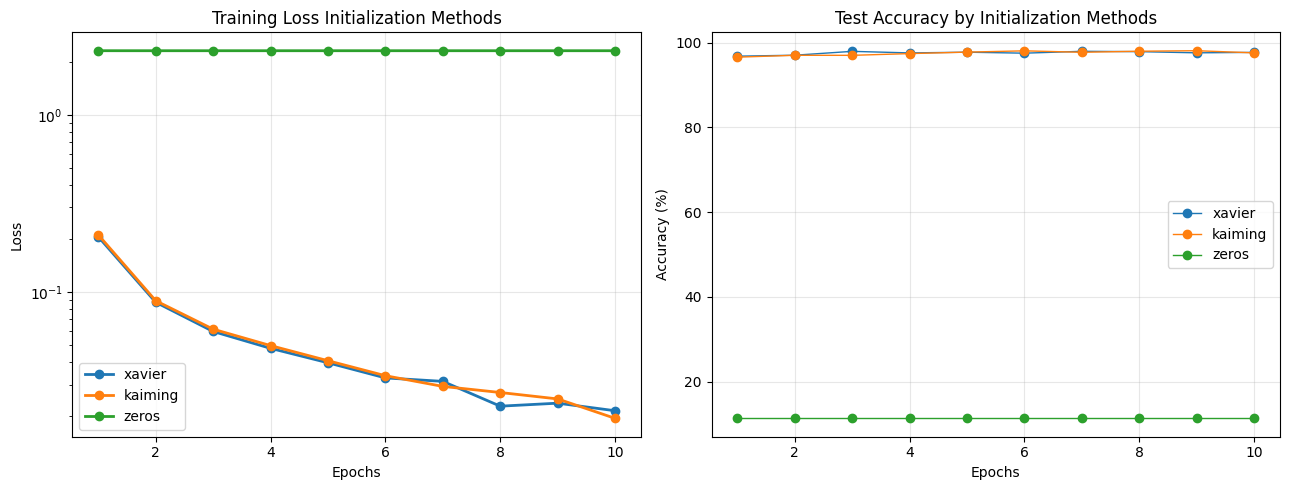

In [47]:
# Bonus: adding visualization comparisons

import matplotlib.pyplot as plt

# ==== Plot loss curves for each initialization method ====
# get figure size 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
epochs = list(range(1, 11)) # 10 epochs 


# plot each method in init_results with a different color and label
for method in init_results:
    losses = init_results[method]['training_losses']
    accuracies = init_results[method]['test_accuracies']
    ax1.plot(epochs, losses, marker='o', linewidth=2, label=f'{method}')
    ax2.plot(epochs, accuracies, marker='o', linewidth=1, label=f'{method}')


# set labels, titles, legends 
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_yscale('log')  # use log scale for better visibility of loss curves
ax1.set_title('Training Loss Initialization Methods')
ax1.legend()

ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Test Accuracy by Initialization Methods')
ax2.legend()

plt.tight_layout()
plt.show()